# 데이터분석 순서(KDD 분석 방법론)
* 데이터 세트 선택: CSV, EXCEL, DB 에서 데이터를 읽어옴
* 데이터 전처리: 데이터타입, 결측값, 이상치탐지, 데이터분포분석, 상관관계
* 데이터 변환(특성추출): 원본 데이터에서 새로운 데이터 생성, 삭제, 스케일링, 구간화
* 데이터 마이닝(모델만들기, 분석): 분석에 적합한 알고리즘 선택, 모델 생성, 튜닝
* 결과 평가: 테스트 데이터를 이용해서 데이터 마이닝으로 만든 모델의 성능 평가

# 데이터 전처리
* 데이터 타입 변환
* 결측치 탐지 및 보간
* 이상치 탐지 및 처리
* 데이터 특성 파악(치우침, 분포 특성)
* 변수들 간의 상관관계 분석

In [12]:
import pandas as pd
import numpy as np

# 1. 데이터 세트 선택 및 로딩
* 데이터 로드 후 head(), tail()로 컬럼과 데이터 파악

In [13]:
data = pd.read_csv("./data/Taitanic_train.csv")
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


# 2. .info()로 컬럼명, 결측치, 데이터 타입 파악

In [14]:
# 데이터가 너무 커서 Non-Null이 표시가 안될 때: show_counts=True
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 3. describe()로 기초통계량 파악(이상치 파악)

In [15]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4. 결측값 찾고, 비율 보고, 대치 / 삭제하기
* 결측값 비율 계산: isna().sum()/len(데이터프레임) * 100
* 결측값 비율이 5% 미만: 행, 열을 제거, 분석에 크게 영향을 미치지 않음
* 결측값 비율이 5% ~ 30%: 결측값을 대체(Imputation)
  * 수치형 데이터(숫자형, 나이, 가격): 평균(mean), 중앙값(median), 최빈값(mode)으로 대체
  * 범주형 데이터(문자형/(숫자형), 선실등급, 탑승지): 최빈값(mode)으로 대체
* 결측값 비율이 30 ~ 50%: 컬럼의 중요도에 따라서 결측값을 대체 혹은 삭제
  * KNN(K-Nearest Neighbor, 최근접이웃) imputer, 회귀분석을 통해 결측값 대체
 * 결측값 비율이 50% 이상: 해당 컬럼 삭제

In [16]:
round(data.isna().sum() / len(data) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

## 결측 데이터의 종류
* MCAR(완전 무작위 결측): 다른 변수와 무관하게 생긴 결측(랜덤, 이유 없음)
  * 설문조사중 일부 응답자가 무작위로 답변을 건너뜀.
* MAR(무작위 결측): 다른 변수와는 관련 있지만 본인과는 무관
  * 나이가 많은 사람들이 소득란에 응답을 하지 않는 경우(나이와 관련)
  * 직업에 따라서 학력란에 응답하지 않는 경우(가정환경, 소득)
* NMAR(비무작위 결측): 변수 자기 자신과 직접 관련이 있는 경우
  * 소득이 낮은 사람이 자신의 소득을 숨기는 경우(소득과 결측이 직접 관련)
  * 체중이 많이 나가는 경우 자신의 체중을 숨기는 경우
  * 만족도가 낮은 고객이 만족도 조사에 응하지 않는 경우
  
**무작정 평균값으로 보간할 수는 없는 노릇!**

## 결측치 처리방법
### 1) 단순대치법(simple imputation)
####  (1) 완전분석: 결측값이 있는 모든 행을 삭제하고 완전한 자료만으로 분석(잘 안씀)
* 결측값을 삭제해도 모델을 만들기에 충분히 많은 데이터가 있는 경우
* 결측값을 삭제한 후에 데이터에 **편향이 없다는 전제**가 있을 때
* dropna(): 결측값이 있는 모든 행 삭제

In [17]:
data.dropna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [18]:
183 / len(data) * 100

20.53872053872054

#### (2) 평균 대치법: 결측치가 있는 컬럼에서 데이터의 평균을 구한 후 결측값을 대치
* 평균을 이용하기 때문에 간편
* 데이터에 이상치가 있을 경우 평균을 이용할 수 없다.
* 데이터에 이상치가 있는 경우 중앙값이나 최빈값을 고려해야 한다.

In [19]:
a = pd.Series([24, 5, 10, 34, 20, 18, 28, 23])
b = pd.Series([24, 5, 10, 34, 20, 18, 28, 2000])

In [20]:
a.mean()

np.float64(20.25)

In [21]:
b.mean()

np.float64(267.375)

In [22]:
sorted(a)

[5, 10, 18, 20, 23, 24, 28, 34]

In [23]:
a.median()

np.float64(21.5)

In [24]:
sorted(b)

[5, 10, 18, 20, 24, 28, 34, 2000]

In [25]:
b.median()

np.float64(22.0)

Age 컬럼의 결측값을 평균 대치법으로 대치<br>
이상치가 크다면, 평균말고 중앙값으로 대치할 수도 있다.

In [26]:
data['Age'].isna().sum()

np.int64(177)

In [27]:
data['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

평균값과 중앙값을 먼저 비교하자!
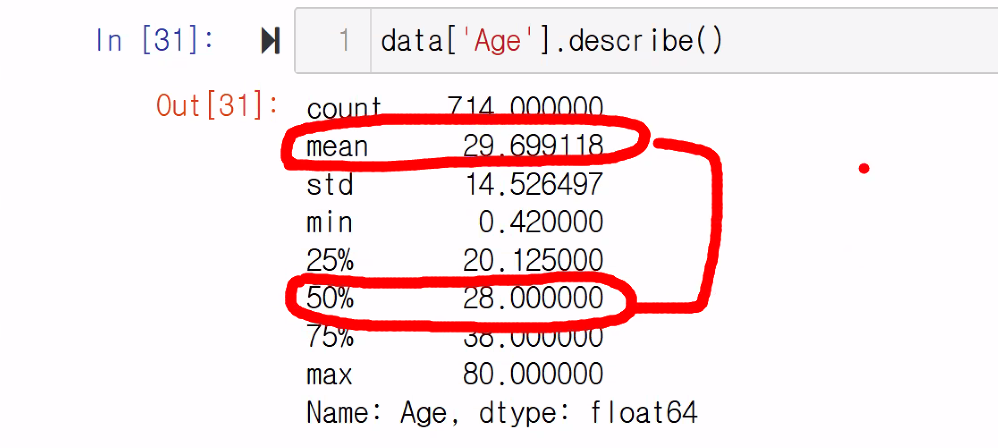

In [28]:
data[data['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [29]:
age_na_idx = data[data['Age'].isna()].index

In [30]:
age_na_idx

Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=177)

In [31]:
# 깊은 복사, 얕은 복사
data_ori = data.copy()
data2 = data.copy()
data3 = data.copy()
data4 = data.copy()
data5 = data.copy()

* 평균값으로 대치

In [32]:
data['Age'] = data['Age'].fillna(data['Age'].mean())

In [33]:
data.loc[age_na_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,29.699118,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,29.699118,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,29.699118,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,29.699118,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,29.699118,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.699118,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,29.699118,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,29.699118,0,0,349217,7.8958,NaN,S


중앙값으로 대치

In [23]:
data2['Age'].median()

np.float64(28.0)

In [33]:
data2['Age'].isna()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888     True
889    False
890    False
Name: Age, Length: 891, dtype: bool

In [34]:
age_na_index2 = data2[data2['Age'].isna()].index

In [35]:
data2['Age'] = data2['Age'].fillna(data2['Age'].median())

In [36]:
data2.loc[age_na_index2]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,28.0,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,28.0,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,28.0,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,28.0,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,28.0,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,28.0,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,28.0,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,28.0,0,0,349217,7.8958,NaN,S


최빈값으로 대치 .mode()

In [39]:
print(type(data4['Age'].mode()))

<class 'pandas.core.series.Series'>


In [40]:
data3['Age'].mode()[0]

np.float64(24.0)

In [37]:
na_idx = data3[data3['Age'].isna()].index
na_idx

Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=177)

In [38]:
na_idx = data3[data3['Age'].isna()].index

In [39]:
data3['Age'] = data3['Age'].fillna(data3['Age'].mode()[0])

In [40]:
data3.loc[na_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,24.0,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,24.0,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,24.0,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,24.0,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,24.0,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,24.0,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,24.0,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,24.0,0,0,349217,7.8958,NaN,S


# scikit-learn의 simple imputer를 이용한 대치

In [41]:
from sklearn.impute import SimpleImputer

In [42]:
# 대괄호를 하나 더 씌어주면 2차원이 된다
imp_mean = SimpleImputer(strategy='mean')
data4['Age'] = imp_mean.fit_transform(data4[['Age']])[:, 0]

In [49]:
data4['Age'].isna().sum()

np.int64(0)

In [43]:
data4.loc[na_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,29.699118,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,29.699118,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,29.699118,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,29.699118,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,29.699118,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.699118,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,29.699118,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,29.699118,0,0,349217,7.8958,NaN,S


In [44]:
imp_median = SimpleImputer(strategy='median')
data3['Age'] = imp_median.fit_transform(data3[['Age']])[:, 0]

In [45]:
data3

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [46]:
data3.loc[na_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,24.0,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,24.0,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,24.0,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,24.0,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,24.0,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,24.0,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,24.0,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,24.0,0,0,349217,7.8958,NaN,S


In [47]:
# 최빈값으로 대치: most_frequent
imp_mode = SimpleImputer(strategy='most_frequent')
data2['Age']= imp_mode.fit_transform(data2[['Age']])[:, 0]

In [48]:
data2.loc[na_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,28.0,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,28.0,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,28.0,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,28.0,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,28.0,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,28.0,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,28.0,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,28.0,0,0,349217,7.8958,NaN,S


In [49]:
imp_mode = SimpleImputer(strategy='most_frequent')
imp_mode.fit_transform(data2[['Age']])[:,0]

array([22.  , 38.  , 26.  , 35.  , 35.  , 28.  , 54.  ,  2.  , 27.  ,
       14.  ,  4.  , 58.  , 20.  , 39.  , 14.  , 55.  ,  2.  , 28.  ,
       31.  , 28.  , 35.  , 34.  , 15.  , 28.  ,  8.  , 38.  , 28.  ,
       19.  , 28.  , 28.  , 40.  , 28.  , 28.  , 66.  , 28.  , 42.  ,
       28.  , 21.  , 18.  , 14.  , 40.  , 27.  , 28.  ,  3.  , 19.  ,
       28.  , 28.  , 28.  , 28.  , 18.  ,  7.  , 21.  , 49.  , 29.  ,
       65.  , 28.  , 21.  , 28.5 ,  5.  , 11.  , 22.  , 38.  , 45.  ,
        4.  , 28.  , 28.  , 29.  , 19.  , 17.  , 26.  , 32.  , 16.  ,
       21.  , 26.  , 32.  , 25.  , 28.  , 28.  ,  0.83, 30.  , 22.  ,
       29.  , 28.  , 28.  , 17.  , 33.  , 16.  , 28.  , 23.  , 24.  ,
       29.  , 20.  , 46.  , 26.  , 59.  , 28.  , 71.  , 23.  , 34.  ,
       34.  , 28.  , 28.  , 21.  , 33.  , 37.  , 28.  , 21.  , 28.  ,
       38.  , 28.  , 47.  , 14.5 , 22.  , 20.  , 17.  , 21.  , 70.5 ,
       29.  , 24.  ,  2.  , 21.  , 28.  , 32.5 , 32.5 , 54.  , 12.  ,
       28.  , 24.  ,

In [50]:
data5.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 결측값 비율이 30~50%일 때 KNN 최근접이웃법

In [51]:
from sklearn.impute import KNNImputer

https://blog.naver.com/smhrd_official/222904288569
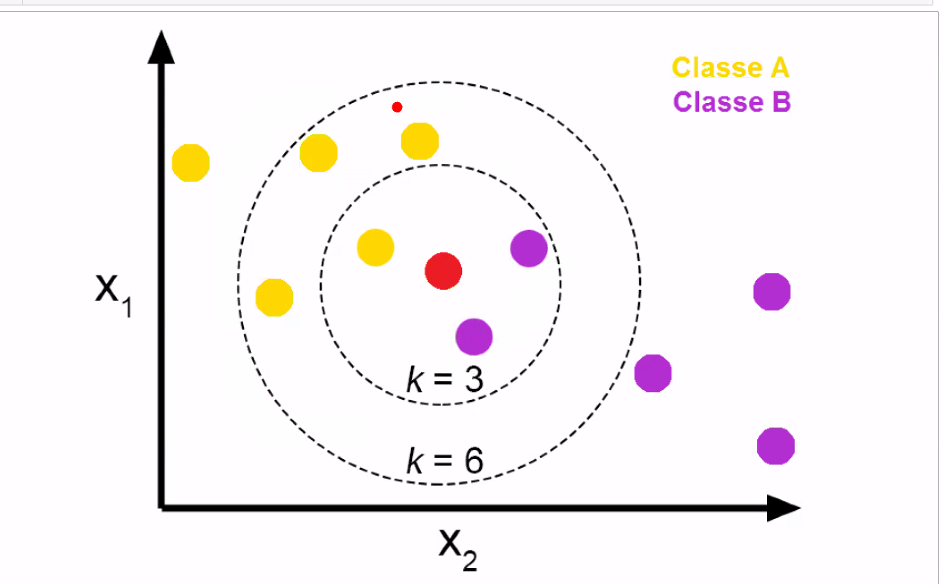

In [84]:
knn_imp = KNNImputer(n_neighbors=5)
data5['Age'] = knn_imp.fit_transform(data5[['Age']])[:, 0]

In [85]:
data5.loc[na_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,29.699118,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,29.699118,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,29.699118,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,29.699118,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,29.699118,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.699118,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,29.699118,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,29.699118,0,0,349217,7.8958,NaN,S


# 깊은 복사, 얕은 복사

In [57]:
# data를 copy()를 이용해서 복사
data_copyed = data_ori.copy()

# data를 다른 변수에 재할당
data_reassigned = data_ori

In [58]:
data_ori['Age'].isna().sum()

np.int64(177)

In [59]:
data_reassigned['Age'].isna().sum()

np.int64(177)

In [60]:
data_reassigned['Age'] = data_reassigned['Age'].fillna(28)

In [61]:
data_reassigned['Age'].isna().sum()

np.int64(0)

In [62]:
data_ori['Age'].isna().sum()

np.int64(0)

In [63]:
data_ori.loc[na_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,28.0,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,28.0,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,28.0,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,28.0,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,28.0,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,28.0,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,28.0,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,28.0,0,0,349217,7.8958,NaN,S


# 실제 메모리상의 주소를 출력 id()

In [64]:
print("data_ori의 메모리 주소: ", id(data_ori))
print("data_reassigned의 메모리 주소: ", id(data_reassigned))
print("data_copyed의 메모리 주소: ", id(data_copyed))

data_ori의 메모리 주소:  2295949958736
data_reassigned의 메모리 주소:  2295949958736
data_copyed의 메모리 주소:  2295952213280


* 얕은 복사를 쓰는 이유는 메모리 낭비를 막기 위해

In [65]:
data_copyed.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [66]:
new_df = data_copyed[['Survived', 'Pclass', 'Name']]
print("data_copyed: ", id(data_copyed))
print("new_df: ", id(new_df))

data_copyed:  2295952213280
new_df:  2296031422064


In [67]:
loc_result = data_copyed.loc[data_copyed['Age'] > 50, ['Name', 'Age']]
slice_result = data_copyed[data_copyed['Age'] > 50][['Name', 'Age']]

In [69]:
loc_result

,Name,Age
6,"McCarthy, Mr. Timothy J",54.0
11,"Bonnell, Miss. Elizabeth",58.0
15,"Hewlett, Mrs. (Mary D Kingcome)",55.0
33,"Wheadon, Mr. Edward H",66.0
54,"Ostby, Mr. Engelhart Cornelius",65.0
...,...,...
820,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",52.0
829,"Stone, Mrs. George Nelson (Martha Evelyn)",62.0
851,"Svensson, Mr. Johan",74.0
857,"Daly, Mr. Peter Denis",51.0


In [70]:
slice_result

,Name,Age
6,"McCarthy, Mr. Timothy J",54.0
11,"Bonnell, Miss. Elizabeth",58.0
15,"Hewlett, Mrs. (Mary D Kingcome)",55.0
33,"Wheadon, Mr. Edward H",66.0
54,"Ostby, Mr. Engelhart Cornelius",65.0
...,...,...
820,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",52.0
829,"Stone, Mrs. George Nelson (Martha Evelyn)",62.0
851,"Svensson, Mr. Johan",74.0
857,"Daly, Mr. Peter Denis",51.0


In [71]:
print("data_copyed:", id(data_copyed))
print("loc_result:", id(loc_result))
print("slice_result:", id(slice_result))

data_copyed: 2295952213280
loc_result: 2296031422592
slice_result: 2295951309264


In [72]:
data.isna().sum() / len(data * 100)

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [73]:
data.drop("Cabin", axis=1, inplace=True)

# 카테고리 변수의 경우 최빈값 .mode()를 이용해 결측값 처리

In [74]:
data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [75]:
cabin_idx = data[data['Embarked'].isna()].index

In [76]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [77]:
data.loc[cabin_idx]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,S
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,S


In [79]:
data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [80]:
data7 = data[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked']]

In [81]:
print(id(data))
print(id(data7))

2295951746000
2296031433968
